In [1]:
from os import chdir
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.colors import BoundaryNorm

chdir(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\failure_probability_contour')

In [2]:
import pathlib
from os import path, getcwd

from tqdm import tqdm
import numpy as np


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    ws, hs, failure_probs = list(), list(), list()
    for folder in tqdm(folders):
        *_, w, h = folder.name.split('-')
        ws.append(float(w))
        hs.append(float(h))
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        failure_probs.append(P_ig)
    return ws, hs, failure_probs


data = dict(
    mdf=read_data(pathlib.Path(getcwd(), 'mdf')),
    macrocarpa=read_data(pathlib.Path(getcwd(), 'macrocarpa')),
)

100%|██████████| 2824/2824 [01:01<00:00, 45.60it/s]


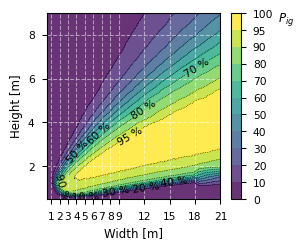

In [3]:
plt.style.use('seaborn-v0_8-paper')

x, y, z = data['mdf']
z = np.array(z) * 100.

# Create a triangulation
triang = tri.Triangulation(x, y)

# Define levels with increments of 10
levels = np.linspace(0, 100, 11)  # [0, 10, 20, ..., 100]
levels = (0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100)

# Choose a built-in colormap
# Options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'turbo'
# Or sequential: 'Blues', 'Greens', 'Oranges', 'Purples', 'Reds'
# Or diverging: 'coolwarm', 'RdBu', 'RdYlBu', 'RdYlGn', 'spectral'
cmap = plt.get_cmap('viridis', len(levels) - 1)  # 10 discrete colors for 10 bands

# Create a BoundaryNorm to map values to colors
norm = BoundaryNorm(levels, len(levels) - 1)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(2.7 * 1.2, 2.7), dpi=96)

# Create contour lines
cs = ax.tricontour(
    x, y, z,
    levels=levels,
    linewidths=0.5, colors='black',
    linestyles='dotted', antialiased=True
)

# Create filled contours with exactly the levels we want
cf = ax.tricontourf(x, y, z, levels=levels, cmap=cmap, norm=norm, alpha=0.8)

# Add contour labels
ax.clabel(cs, cs.levels, inline=True, fmt=lambda x: f'{x:.0f} %', fontsize=8, manual=False, use_clabeltext=True)
ax.set_xticks(list(range(1, 9, 1)) + list(range(9, 22, 3)))
ax.set_xlabel(r'Width [m]')
ax.set_ylabel('Height [m]')
ax.set_xlim(0.5, 21)
ax.set_ylim(0.5, 9)
ax.grid(True, linestyle='--', color='white', alpha=0.5)

# Create colorbar with ticks at each level
cbar = plt.colorbar(cf, ax=ax, ticks=levels)
cbar.set_label('$P_{ig}$', rotation=0, labelpad=10, y=1.015)

plt.tight_layout()
plt.show()

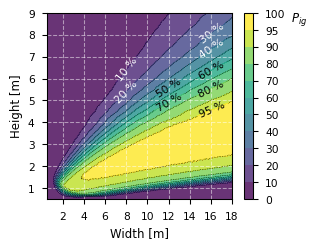

In [4]:
x, y, z = data['mdf']
z = np.array(z) * 100.

# Create a triangulation
triang = tri.Triangulation(x, y)

# Define levels with increments of 10
levels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]

# Choose a built-in colormap
# Options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'turbo'
# Or sequential: 'Blues', 'Greens', 'Oranges', 'Purples', 'Reds'
# Or diverging: 'coolwarm', 'RdBu', 'RdYlBu', 'RdYlGn', 'spectral'
cmap = plt.get_cmap('viridis', len(levels) - 1)  # 10 discrete colors for 10 bands

# Create a BoundaryNorm to map values to colors
norm = BoundaryNorm(levels, len(levels) - 1)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(2.7 * 1.2, 2.7), dpi=96)

# Create contour lines
cs = ax.tricontour(
    x, y, z,
    levels=levels, linewidths=0.5, colors='black', linestyles='dotted', antialiased=True
)

# Create filled contours with exactly the levels we want
cf = ax.tricontourf(x, y, z, levels=levels, cmap=cmap, norm=norm, alpha=0.8)

# Add contour labels
ax.set_xticks(list(range(0, 22, 2)))
ax.set_xlabel(r'Width [m]')
ax.set_ylabel('Height [m]')
ax.set_xlim(.5, 18)
ax.set_ylim(.5, 9)
ax.set_yticks(range(1, 10, 1))
ax.grid(True, linestyle='--', color='white', alpha=0.5)

# Create colorbar with ticks at each level
cbar = plt.colorbar(cf, ax=ax, ticks=levels)
cbar.set_label('$P_{ig}$', rotation=0, labelpad=10, y=1.015)
colors = ['k'] * len(levels)
for i in range(5):
    colors[i] = 'w'

manual = (
    (7.987489561504405, 6.450013392786802),
    (8.025115414309798, 5.438621645894717),
    (16.130997211149104, 8.079931302881812),
    (16.100556194557804, 7.370554776498022),
    (16.071312650668848, 6.374383537901586),
    (16.041438857989192, 5.529156884680226),
    (16.145618983093577, 4.57801692218003),
    (12.0662076354641, 5.597034679439708),
    (12.069169804780437, 4.887595128176847),
)
# manual = ((5.9, 5), (7.1, 5), (8.2, 5), (9.1, 5), (10.1, 5), (11.1, 5), (12.2, 5), (13.8, 5), (15.8, 5), (13, 3.7))
ax.clabel(
    cs, cs.levels, inline=True, fmt=lambda x: f'{x:.0f} %', fontsize=8, manual=manual, use_clabeltext=True,
    colors=colors
)

fig.tight_layout()

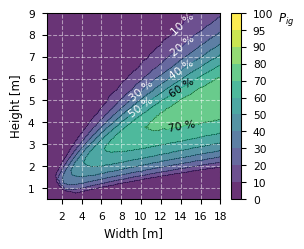

In [6]:
x, y, z = data['macrocarpa']
z = np.array(z) * 100.

# Create a triangulation
triang = tri.Triangulation(x, y)

# Define levels with increments of 10
levels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]

# Choose a built-in colormap
# Options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'turbo'
# Or sequential: 'Blues', 'Greens', 'Oranges', 'Purples', 'Reds'
# Or diverging: 'coolwarm', 'RdBu', 'RdYlBu', 'RdYlGn', 'spectral'
cmap = plt.get_cmap('viridis', len(levels) - 1)  # 10 discrete colors for 10 bands

# Create a BoundaryNorm to map values to colors
norm = BoundaryNorm(levels, len(levels) - 1)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(2.7 * 1.2, 2.7), dpi=96)

# Create contour lines
cs = ax.tricontour(
    x, y, z,
    levels=levels,
    linewidths=0.5, colors='black',
    linestyles='dotted', antialiased=True
)

# Create filled contours with exactly the levels we want
cf = ax.tricontourf(x, y, z, levels=levels, cmap=cmap, norm=norm, alpha=0.8)

# Add contour labels
ax.set_xticks(list(range(0, 22, 2)))
ax.set_xlabel(r'Width [m]')
ax.set_ylabel('Height [m]')
ax.set_xlim(.5, 18)
ax.set_ylim(.5, 9)
ax.set_yticks(range(1, 10, 1))
ax.grid(True, linestyle='--', color='white', alpha=0.5)

# Create colorbar with ticks at each level
cbar = plt.colorbar(cf, ax=ax, ticks=levels)
cbar.set_label('$P_{ig}$', rotation=0, labelpad=10, y=1.015)
colors = ['k'] * len(levels)
for i in range(6):
    colors[i] = 'w'

manual = (
    (14.15091009376724, 8.489937751162243),
    (14.17618784965724, 7.510629580017337),
    (14.100039397998579, 6.4108896068079755),
    (14.159798282247266, 5.552076274525255),
    (10.108486328894493, 5.420297848869279),
    (10.068710109526435, 4.667039634386574),
    (14.14529981876921, 3.8195098888976453),
)
ax.clabel(
    cs, cs.levels, inline=True, fmt=lambda x: f'{x:.0f} %', fontsize=8, manual=manual, use_clabeltext=True,
    colors=colors
)

fig.tight_layout()